# Laboratorio: Búsqueda en entornos complejos

## Búsqueda Local 

En este laboratorio se estudiarán algoritmos de búsqueda local y heurística en un entorno de espacio de estados complejo. El problema elegido es el de las 8 reinas, en el cual se deben ubicar 8 reinas sobre un tablero de ajedrez de 8x8 de manera que ninguna reina pueda atacar a otra. 

A diferencia de los métodos de búsqueda sistemática, los algoritmos de búsqueda local no construyen explícitamente un árbol completo, sino que exploran el espacio de estados moviéndose entre configuraciones vecinas. 

## Descripción del problema

El problema de las 8 reinas consiste en colocar 8 reinas sobre un tablero de 8x8 de forma que:
- no compartan la misma fila
- no compartan la misma columna
- no compartan la misma diagonal.

*Representación del estado*

Cada estado se representará como un arreglo de longitud 8:



In [21]:
estado = [0, 4, 7, 5, 2, 6, 1, 3]

significa:
- en la columna 0 hay una reina en la fila 0,
- en la columna 1 hay una reina en la fila 4,
- ...
- en la columna 7 hay una reina en la fila 3.

## Implementación

*En parejas*, deberán implementar: 
- Hill Climbing
- Una variación del Hill Climbing (Stochastic/ First-choice/ Random-restart)
- Beam Search con beam width = _k_

Cada grupo debe realizar experimentos comparativos entre los algoritmos implementados.

### Experimentos requeridos:

Ejecutar cada algoritmo 1000 veces con estados iniciales aleatorios y reportar:

- porcentaje de éxito,
- promedio de largo de episodio (hasta éxito o estancarse)
- promedio de valor heurístico final,
- tiempo promedio de ejecución.

Para Beam Search, repetir los experimentos con distintos valores de _k_ (2,5,10). 

## Discuta 

¿Qué tan frecuentemente Hill Climbing encuentra una solución?

¿Qué tipo de problemas presenta Hill Climbing en este dominio?

¿La variante elegida mejora el desempeño? ¿Por qué?

¿Cómo afecta el valor de k en Beam Search?

¿Cuál algoritmo resultó más efectivo?

¿Qué relación existe entre costo computacional y tasa de éxito?

## Funciones útiles

In [22]:
def es_solucion(estado):
    """
    Verifica si un estado representa una solución válida al problema
    de las 8 reinas.

    Parámetros:
        estado (list): lista de 8 enteros, donde el índice representa
                       la columna y el valor representa la fila.

    Retorna:
        bool: True si es una solución válida, False en caso contrario.
    """
    if not isinstance(estado, list) or len(estado) != 8:
        return False

    # Verificar que todas las filas sean enteros entre 0 y 7
    for fila in estado:
        if not isinstance(fila, int) or fila < 0 or fila > 7:
            return False

    n = 8

    for c1 in range(n):
        for c2 in range(c1 + 1, n):
            r1 = estado[c1]
            r2 = estado[c2]

            # Misma fila
            if r1 == r2:
                return False

            # Misma diagonal
            if abs(r1 - r2) == abs(c1 - c2):
                return False

    return True


def heuristica(estado):
    """
    Calcula el número de pares de reinas que se atacan entre sí.
    Un estado solución tiene heurística 0.
    """
    conflictos = 0
    n = 8

    for c1 in range(n):
        for c2 in range(c1 + 1, n):
            r1 = estado[c1]
            r2 = estado[c2]

            if r1 == r2 or abs(r1 - r2) == abs(c1 - c2):
                conflictos += 1

    return conflictos

## Herramientas

In [23]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

# UTILIDADES
def generar_estado_aleatorio():
    return [random.randint(0, 7) for _ in range(8)]

def obtener_vecinos(estado):
    vecinos = []
    for col in range(8):
        fila_original = estado[col]
        for fila_nueva in range(8):
            if fila_nueva != fila_original:
                nuevo_vecino = list(estado)
                nuevo_vecino[col] = fila_nueva
                vecinos.append(nuevo_vecino)
    return vecinos

# HILL CLIMBING
def hill_climbing(estado_inicial, max_pasos=100):
    actual = list(estado_inicial)
    pasos = 0
    
    while pasos < max_pasos:
        vecinos = obtener_vecinos(actual)
        mejor_vecino = min(vecinos, key=heuristica)
        
        if heuristica(mejor_vecino) >= heuristica(actual):
            break
            
        actual = mejor_vecino
        pasos += 1
        
        if heuristica(actual) == 0:
            return actual, pasos, True
            
    return actual, pasos, False

# RANDOM RESTART HC
def random_restart_hill_climbing(max_restarts=10):
    total_pasos = 0
    mejor_estado = None
    mejor_h = float('inf')
    
    for _ in range(max_restarts):
        res, pasos, exito = hill_climbing(generar_estado_aleatorio())
        total_pasos += pasos
        
        h = heuristica(res)
        if h < mejor_h:
            mejor_h = h
            mejor_estado = res
        
        if exito:
            return res, total_pasos, True
    
    return mejor_estado, total_pasos, False

# ========================
# BEAM SEARCH
# ========================

def beam_search(k=5, max_pasos=200):
    haz = [generar_estado_aleatorio() for _ in range(k)]
    pasos = 0
    
    while pasos < max_pasos:
        pasos += 1
        candidatos = []
        
        for estado in haz:
            candidatos.extend(obtener_vecinos(estado))
        
        # eliminar duplicados
        candidatos = list({tuple(c): c for c in candidatos}.values())
        
        candidatos.sort(key=heuristica)
        haz = candidatos[:k]
        
        if heuristica(haz[0]) == 0:
            return haz[0], pasos, True
    
    return haz[0], pasos, False

## Experimentos

In [24]:
# EXPERIMENTOS
# ========================

def ejecutar_experimento(algoritmo_func, nombre, iteraciones=1000, **kwargs):
    exitos = 0
    pasos_totales = []
    heuristica_final = []
    tiempos = []
    
    mejor_estado = None
    mejor_h = float('inf')
    
    for _ in range(iteraciones):
        start = time.time()
        
        if nombre == "Hill Climbing":
            res, pasos, exito = algoritmo_func(generar_estado_aleatorio())
        else:
            res, pasos, exito = algoritmo_func(**kwargs)
        
        end = time.time()
        
        if exito:
            exitos += 1
        
        pasos_totales.append(pasos)
        h = heuristica(res)
        heuristica_final.append(h)
        tiempos.append(end - start)
        
        if h < mejor_h:
            mejor_h = h
            mejor_estado = res
    
    print(f"\n--- {nombre} ---")
    print(f"Éxito: {exitos/iteraciones*100}%")
    print(f"Pasos promedio: {np.mean(pasos_totales):.2f}")
    print(f"Heurística final promedio: {np.mean(heuristica_final):.2f}")
    print(f"Tiempo promedio: {np.mean(tiempos)*1000:.2f} ms")
    
    return mejor_estado

## Ejecución

In [25]:
ultima_solucion_hc = ejecutar_experimento(hill_climbing, "Hill Climbing")
ultima_solucion_rr = ejecutar_experimento(random_restart_hill_climbing, "Random Restart HC", max_restarts=10)
ultima_solucion_beam = ejecutar_experimento(beam_search, "Beam Search (k=5)", k=5)



--- Hill Climbing ---
Éxito: 15.9%
Pasos promedio: 3.28
Heurística final promedio: 1.21
Tiempo promedio: 0.60 ms

--- Random Restart HC ---
Éxito: 79.80000000000001%
Pasos promedio: 17.75
Heurística final promedio: 0.20
Tiempo promedio: 2.88 ms

--- Beam Search (k=5) ---
Éxito: 77.3%
Pasos promedio: 48.69
Heurística final promedio: 0.23
Tiempo promedio: 29.76 ms


## Visualización

Visualización de la mejor solución encontrada (Beam Search):


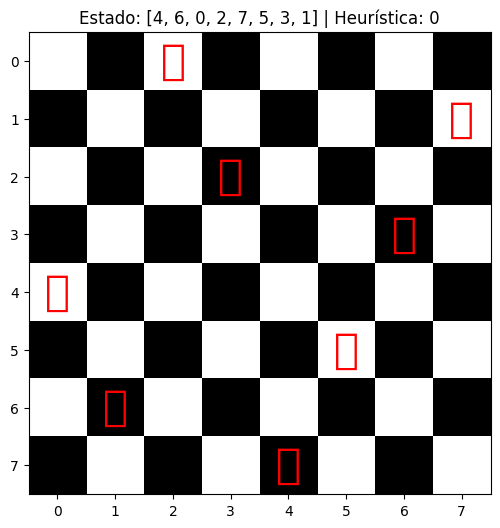

In [26]:
# VISUALIZACIÓN
def dibujar_tablero(estado):
    n = len(estado)
    tablero = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                tablero[i, j] = 0.8
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(tablero, cmap='gray', origin='upper')
    
    for col, fila in enumerate(estado):
        ax.text(col, fila, '👑', fontsize=30, ha='center', va='center', color='red')
        
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_title(f"Estado: {estado} | Heurística: {heuristica(estado)}")
    plt.show()

print("Visualización de la mejor solución encontrada (Beam Search):")
dibujar_tablero(ultima_solucion_beam)